# Video Game Market Insights: Strategic Data Analysis for Ice Store

## Table of Contents
1. [**Project Overview & Data Description**](#data-description)
    * Defining objectives and understanding the variables.
2. [**Step 1: Data Wrangling & Preprocessing**](#step-1-data-preparation)
    * Normalizing column schema, handling missing values, and optimizing data types for analysis.
3. [**Step 2: Exploratory Data Analysis (EDA)**](#step-2-eda)
    * Mapping platform lifecycles and historical sales trends.
    * Identifying the strategic timeframe for the 2017 inventory planning.
    * Analyzing the correlation between critic/user reviews and commercial performance.
4. [**Step 3: Regional Consumer Profiling**](#step-3-regional-profiling)
    * Market share breakdown across North America (NA), Europe (EU), and Japan (JP).
    * Evaluating the impact of ESRB ratings on regional revenue.
5. [**Step 4: Statistical Hypothesis Testing**](#step-4-hypothesis-testing)
    * Comparative analysis: Xbox One vs. PC user satisfaction.
    * Genre performance: Action vs. Sports (Is there a significant difference?).
6. [**Overall Conclusion & Strategic Recommendations**](#general-conclusion)

## Introduction
This project aims to identify the key success drivers within the video game industry by leveraging historical datasets, including sales figures, user/critic reviews, and platform trends. The primary objective is to analyze historical data up to 2016 to derive actionable insights for planning a data-driven advertising campaign for 2017.

## Step 1: Environment Setup & Data Acquisition
In this stage, we configure the analytical environment by importing essential libraries and loading the raw dataset for an initial diagnostic inspection.

## Data Dictionary

The dataset encompasses historical game sales, expert and user evaluations, and age ratings. Below is a detailed description of the features:

* **Name:** Title of the game.
* **Platform:** Launch console or hardware platform.
* **Year_of_Release:** The year the game was officially released.
* **Genre:** Game category (e.g., Action, Sports, RPG).
* **NA_sales:** Sales in North America (in millions of USD).
* **EU_sales:** Sales in Europe (in millions of USD).
* **JP_sales:** Sales in Japan (in millions of USD).
* **Other_sales:** Sales in the rest of the world (in millions of USD).
* **Critic_Score:** Aggregate score from specialized media (scale: 0–100).
* **User_Score:** Average score given by players (scale: 0–10).
* **Rating:** ESRB maturity rating (e.g., E, T, M).

> **Note:** Data for the year 2016 may be incomplete at the time of collection. This limitation was carefully considered during the trend analysis and forecasting stages.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

import os

# Definindo o caminho relativo correto para a sua pasta 'data'
file_path = 'data/games.csv'

# Verificando se o arquivo existe antes de carregar
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("Arquivo carregado com sucesso da pasta /data!")
else:
    # Caso você execute o notebook de dentro da própria pasta 'notebooks', 
    # precisamos subir um nível para achar a pasta 'data'
    df = pd.read_csv('../data/games.csv')
    print("Arquivo carregado com sucesso usando caminho relativo!")

# Visualizando os dados
display(df.head())
df.info()

Arquivo carregado com sucesso usando caminho relativo!


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### 1.1. Data Integrity & Cleaning Requirements

Upon initial inspection, the following technical inconsistencies were identified and prioritized for correction:

* **Column Standardization:** Features are currently using inconsistent casing. We will normalize all column names to **snake_case** (lowercase) to ensure coding best practices and prevent syntax errors.
* **Data Type Optimization:** * `Year_of_Release` is stored as a float; it will be converted to **integers** for chronological accuracy.
    * `User_Score` is currently an object (string); it must be cast to **numeric** to enable statistical calculations.
* **Handling Missing Values:** A significant volume of null values was detected in `Critic_Score`, `User_Score`, and `Rating`. We will evaluate the nature of these gaps to apply the most appropriate imputation or filtering strategy, ensuring the analysis remains unbiased.

## Step 2: Data Engineering & Wrangling

### 2.1. Feature Schema Standardization
To streamline data manipulation and adhere to Pythonic best practices, we will normalize the column schema by converting all headers to lowercase. This ensures a consistent syntax for subsequent analytical functions.

### 2.2. Type Casting & Strategic Handling of Missing Values
Our diagnostic revealed that `year_of_release` contains null values and is currently stored as a float. Since null values (NaN) cannot be converted to integers and the missing data in the `name` and `year_of_release` columns represents a negligible fraction of the dataset, we will execute a targeted removal of these records. This action guarantees the integrity of our chronological analysis without compromising the overall statistical power.

In [82]:
# 1. Transformando nomes das colunas em minúsculo
df.columns = df.columns.str.lower()

# 2. Removendo linhas com valores ausentes em colunas críticas (nome e ano)
# Como são poucos registros (apenas 2 nomes e cerca de 269 anos), a exclusão não afetará a análise.
df.dropna(subset=['name', 'year_of_release'], inplace=True)

# 3. Convertendo o ano para inteiro
df['year_of_release'] = df['year_of_release'].astype(int)

# Verificando as mudanças
print("Colunas atualizadas:", df.columns.tolist())
print("\nNovos tipos de dados:")
print(df.dtypes[['name', 'year_of_release']])

Colunas atualizadas: ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']

Novos tipos de dados:
name               object
year_of_release     int64
dtype: object


### 2.3. Processing 'user_score' and Handling the 'TBD' Placeholder
The abbreviation "TBD" (To Be Determined) indicates that a score has not yet been assigned. To maintain statistical consistency, we will treat these entries as null values (NaN). This enables us to cast the entire column to a **numeric (float)** data type, allowing for precise mathematical operations and correlation analysis.

### 2.4. Feature Engineering: Calculating Aggregate Global Sales
To provide a holistic view of commercial performance, we will engineer a new feature named `total_sales`. This metric represents the aggregate revenue across all key territories: North America, Europe, Japan, and other regions. This unified KPI will serve as our primary dependent variable for the upcoming analysis.

In [83]:
# 1. Tratando o "TBD" na coluna user_score
# Substituímos 'tbd' por NaN e convertemos para float
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# 2. Calculando o total de vendas (soma das colunas de vendas regionais)
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

# Verificando o resultado
print("Verificação de tipos após conversão:")
print(df[['user_score', 'total_sales']].dtypes)
print("\nPrimeiras linhas com a nova coluna 'total_sales':")
display(df[['name', 'platform', 'total_sales']].head())

Verificação de tipos após conversão:
user_score     float64
total_sales    float64
dtype: object

Primeiras linhas com a nova coluna 'total_sales':


,name,platform,total_sales
0,Wii Sports,Wii,82.54
1,Super Mario Bros.,NES,40.24
2,Mario Kart Wii,Wii,35.52
3,Wii Sports Resort,Wii,32.77
4,Pokemon Red/Pokemon Blue,GB,31.38


## Step 3: Exploratory Data Analysis (EDA)

### 3.1. Temporal Analysis: Game Release Volume per Year
To decode market dynamics over time, we will analyze the volume of game releases across different periods. This longitudinal view is essential to determine the data's relevance and identify the optimal historical threshold required to build a reliable predictive model for 2017.

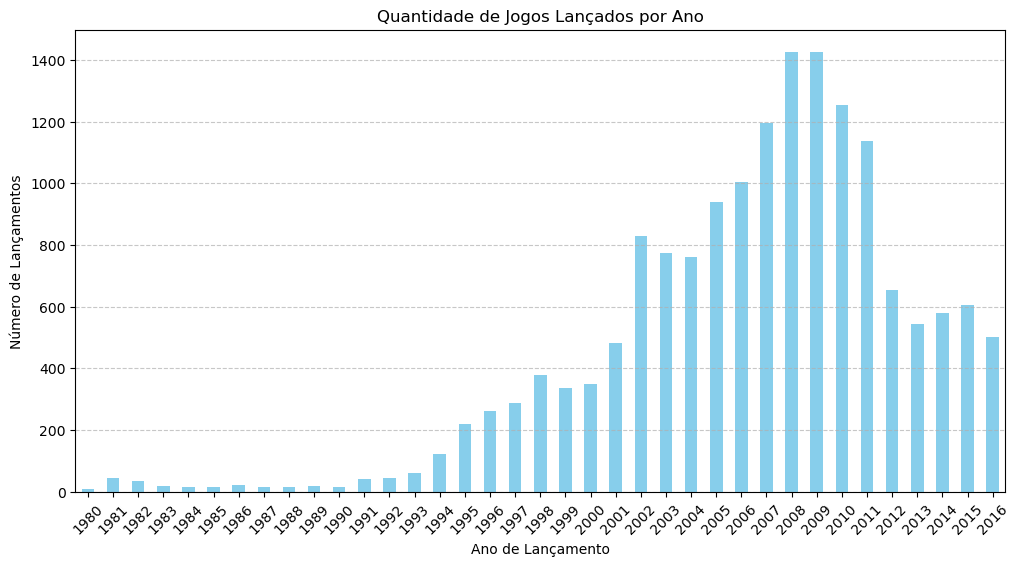

Lançamentos nos últimos 10 anos registrados:
year_of_release
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


In [84]:
# Agrupando os jogos por ano de lançamento e contando a quantidade
games_per_year = df.groupby('year_of_release')['name'].count()

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
games_per_year.plot(kind='bar', color='skyblue', rot=45)
plt.title('Quantidade de Jogos Lançados por Ano')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Número de Lançamentos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Exibindo os números absolutos dos anos mais recentes para análise
print("Lançamentos nos últimos 10 anos registrados:")
print(games_per_year.tail(10))

### 3.2. Market Share by Platform and Lifecycle Dynamics
We will identify the industry-leading platforms by total sales to understand how console popularity evolves over time. This analysis is crucial for calculating the average lifespan of a platform, allowing us to distinguish between emerging technologies and those entering a period of market obsolescence.

Top 10 plataformas em vendas totais:
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64


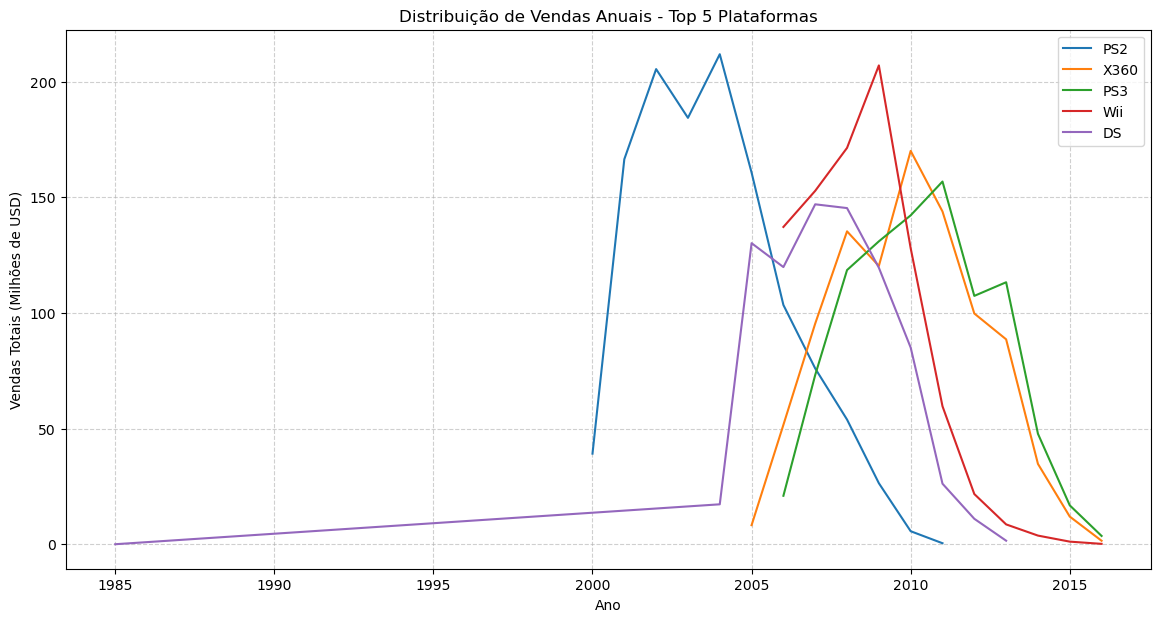

In [85]:
# 1. Identificando as 10 plataformas com maiores vendas totais
top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 plataformas em vendas totais:")
print(top_platforms)

# 2. Criando uma distribuição de vendas anuais para as 5 principais plataformas
top_5_list = top_platforms.head(5).index.tolist()

plt.figure(figsize=(14, 7))
for platform in top_5_list:
    yearly_sales = df[df['platform'] == platform].groupby('year_of_release')['total_sales'].sum()
    yearly_sales.plot(label=platform)

plt.title('Distribuição de Vendas Anuais - Top 5 Plataformas')
plt.xlabel('Ano')
plt.ylabel('Vendas Totais (Milhões de USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 3.3. Defining the Strategic Analysis Period
Based on our observation that platform lifecycles average 10 years, we will filter our dataset to focus on data from 2014 onwards. This strategic pivot allows us to concentrate on the current hardware generation (e.g., PS4, Xbox One) and identify growth or decline trends that will remain actionable for our 2017 planning.

### 3.4. High-Potential Platforms for 2017
We will analyze which platforms dominate sales within our selected timeframe and evaluate their profitability potential to identify the market leaders for the upcoming year.

### 3.5. Global Sales Distribution Analysis (Boxplots)
To gain deeper insights into sales variance, we will utilize Boxplots. This visualization goes beyond simple averages, allowing us to analyze data dispersion and identify "outliers"—those massive commercial hits that represent significant market opportunities on each platform.

In [86]:
# Após reiniciar o Kernel, tive um erro, por isso filtrei os dados para essa análise
# Filtrando dados para o período relevante (2014-2016)

df_recent = df[df['year_of_release'] >= 2014]

print(f"Dados originais: {len(df)} registros")
print(f"Dados recentes (2014-2016): {len(df_recent)} registros")

Dados originais: 16444 registros
Dados recentes (2014-2016): 1689 registros


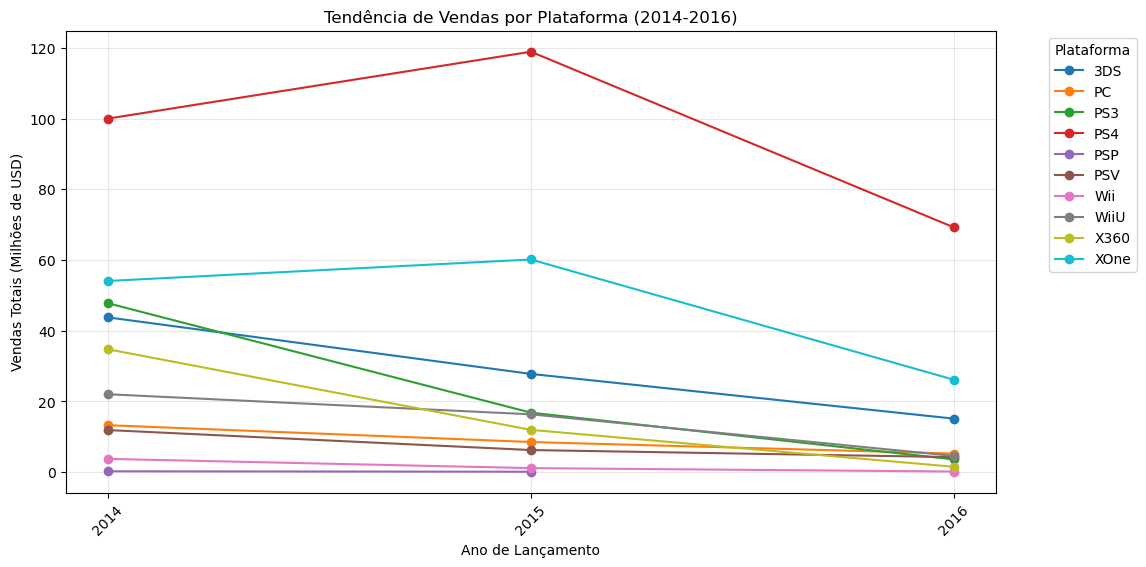

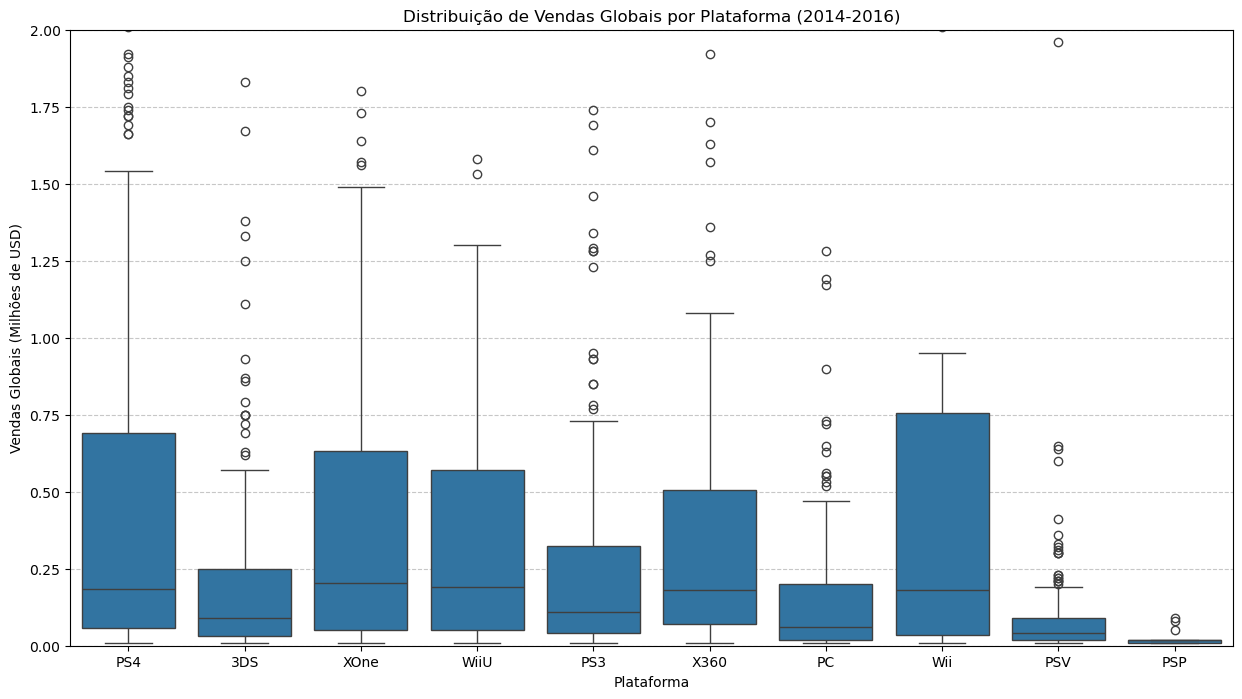

In [87]:
# 1. Gráfico de Tendências com Eixo X corrigido e Rotação
pivot_recent = df_recent.pivot_table(index='year_of_release', 
                                    columns='platform', 
                                    values='total_sales', 
                                    aggfunc='sum')

plt.figure(figsize=(12, 6))
for platform in pivot_recent.columns:
    plt.plot(pivot_recent.index, pivot_recent[platform], marker='o', label=platform)

# Ajustando o Eixo X para mostrar apenas anos inteiros e rotacionar
plt.xticks(pivot_recent.index, rotation=45) 
plt.title('Tendência de Vendas por Plataforma (2014-2016)')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Vendas Totais (Milhões de USD)')
plt.legend(title='Plataforma', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Criando o Boxplot para vendas globais por plataforma
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_recent, x='platform', y='total_sales')
plt.title('Distribuição de Vendas Globais por Plataforma (2014-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Vendas Globais (Milhões de USD)')
# Limitando o eixo Y para melhor visualização, pois existem sucessos muito fora da curva
plt.ylim(0, 2) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.6. Strategic Insights from Global Sales Distribution (Boxplots)
Analyzing the distribution of global sales per platform for the 2014-2016 period reveals key market dynamics:

* **Low Baseline, High Ceiling:** Median sales for most platforms remain relatively low, typically concentrated below 250,000 units per title.
* **The "Blockbuster" Effect:** Platforms such as **PS4** and **Xbox One** exhibit larger interquartile ranges and a significant volume of outliers. This indicates a higher frequency of "AAA" or "Blockbuster" titles that achieve multi-million unit sales.
* **Profit Concentration:** The notable gap between average sales and total revenue suggests that market success is heavily driven by a small cohort of elite, high-performing titles.

### 3.7. Impact Analysis: How Reviews Influence Commercial Success (Case Study: PS4)
To evaluate the degree of influence that professional critics and user sentiment have on revenue, we will conduct a deep dive into the **PS4** platform. We will utilize scatter plots to visualize these relationships and calculate the **Pearson Correlation Coefficient** to quantify the strength and direction of these associations.

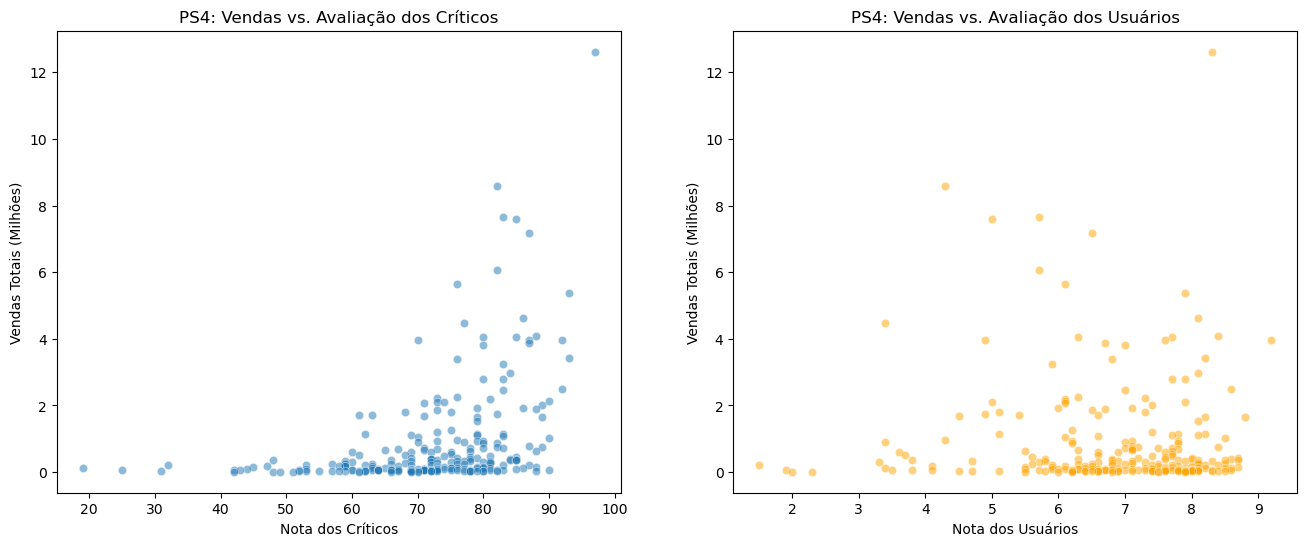

Correlação entre Vendas e Críticos: 0.40
Correlação entre Vendas e Usuários: -0.04


In [88]:
# 1. Filtrando dados apenas do PS4 e removendo nulos nas notas para o cálculo
ps4_data = df_recent[(df_recent['platform'] == 'PS4') & 
                     (df_recent['critic_score'].notna()) & 
                     (df_recent['user_score'].notna())]

# 2. Criando os gráficos de dispersão
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Vendas vs. Avaliação dos Críticos
sns.scatterplot(data=ps4_data, x='critic_score', y='total_sales', ax=ax[0], alpha=0.5)
ax[0].set_title('PS4: Vendas vs. Avaliação dos Críticos')
ax[0].set_xlabel('Nota dos Críticos')
ax[0].set_ylabel('Vendas Totais (Milhões)')

# Vendas vs. Avaliação dos Usuários
sns.scatterplot(data=ps4_data, x='user_score', y='total_sales', ax=ax[1], alpha=0.5, color='orange')
ax[1].set_title('PS4: Vendas vs. Avaliação dos Usuários')
ax[1].set_xlabel('Nota dos Usuários')
ax[1].set_ylabel('Vendas Totais (Milhões)')

plt.show()

# 3. Calculando a correlação
corr_critic = ps4_data['critic_score'].corr(ps4_data['total_sales'])
corr_user = ps4_data['user_score'].corr(ps4_data['total_sales'])

print(f"Correlação entre Vendas e Críticos: {corr_critic:.2f}")
print(f"Correlação entre Vendas e Usuários: {corr_user:.2f}")

### 3.8. Cross-Platform Correlation Benchmark
To determine if the insights derived from the PS4 analysis reflect a broader market trend, we will conduct a comparative correlation study across **Xbox One (XOne)** and **PC**. This cross-platform validation is essential to verify if the weight of professional reviews is a consistent global driver for commercial success.

In [89]:
# Função para calcular correlação rapidamente em diferentes plataformas
def check_correlation(platform_name):
    temp_df = df_recent[(df_recent['platform'] == platform_name) & 
                        (df_recent['critic_score'].notna()) & 
                        (df_recent['user_score'].notna())]
    
    corr_critic = temp_df['critic_score'].corr(temp_df['total_sales'])
    corr_user = temp_df['user_score'].corr(temp_df['total_sales'])
    
    print(f"--- Plataforma: {platform_name} ---")
    print(f"Correlação Vendas vs. Críticos: {corr_critic:.2f}")
    print(f"Correlação Vendas vs. Usuários: {corr_user:.2f}\n")

# Testando para XOne e PC
check_correlation('XOne')
check_correlation('PC')

--- Plataforma: XOne ---
Correlação Vendas vs. Críticos: 0.42
Correlação Vendas vs. Usuários: -0.09

--- Plataforma: PC ---
Correlação Vendas vs. Críticos: 0.17
Correlação Vendas vs. Usuários: -0.09



### 3.8. Cross-Platform Correlation Benchmark: Validating Market Trends
Following the PS4 analysis, it is essential to determine whether the influence of professional reviews on sales is an isolated phenomenon or a consistent market trend. To verify this, we will apply the same statistical rigor to the **Xbox One (XOne)** and **PC** platforms, comparing the **Pearson Correlation Coefficients** between global revenue and both critic and user scores.

### 3.9. Genre Profitability Analysis
To conclude the Exploratory Data Analysis (EDA), we will examine the distribution of games by genre. The objective is to identify the most lucrative categories and determine if there is a significant discrepancy between the volume of releases and the actual sales revenue within each genre.

Análise de vendas por Gênero (Ordenado pela Mediana):


,count,sum,mean,median
genre,,,,
Shooter,128,170.94,1.335469,0.515
Sports,161,109.48,0.680000,0.180
Platform,38,18.09,0.476053,0.140
Fighting,60,28.22,0.470333,0.125
Role-Playing,221,101.44,0.459005,0.110
Simulation,44,13.13,0.298409,0.100
Action,619,199.36,0.322068,0.090
Misc,113,37.55,0.332301,0.090
Racing,69,27.52,0.398841,0.090


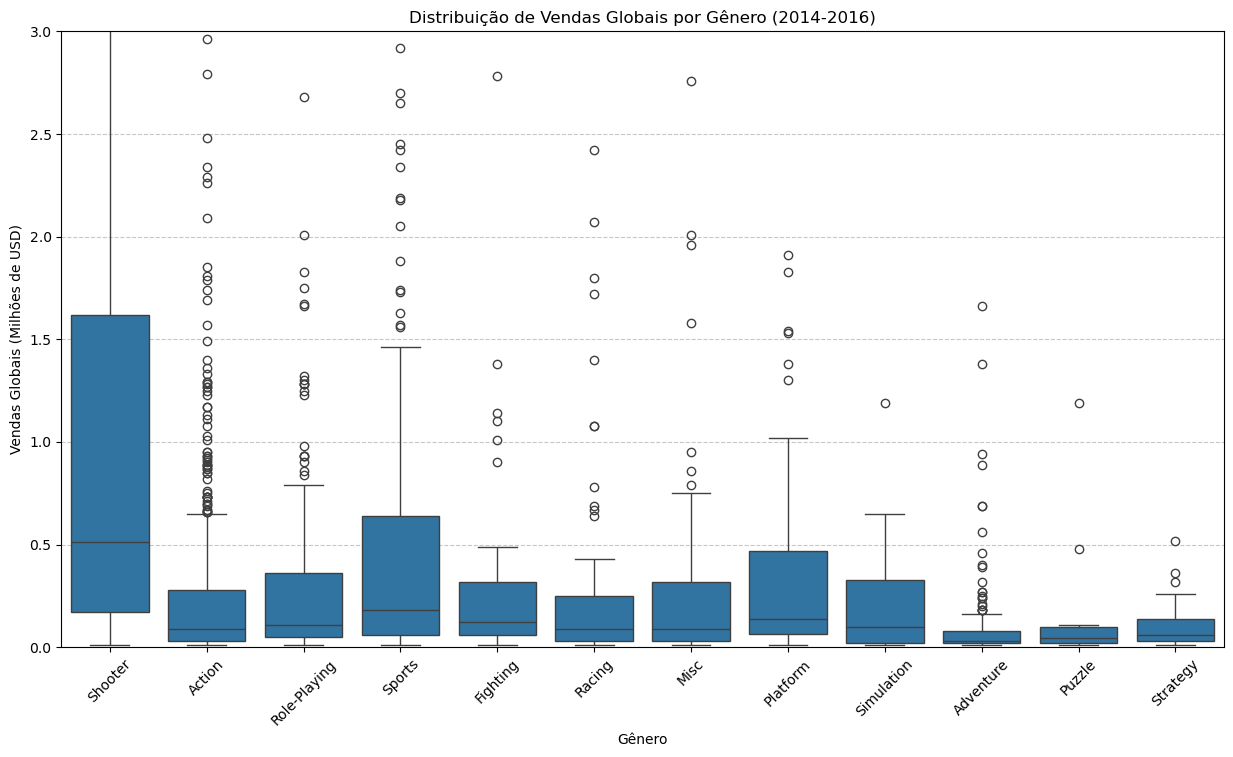

In [90]:
# 1. Agrupando por gênero e calculando métricas de vendas
genre_analysis = df_recent.groupby('genre')['total_sales'].agg(['count', 'sum', 'mean', 'median']).sort_values(by='median', ascending=False)

print("Análise de vendas por Gênero (Ordenado pela Mediana):")
display(genre_analysis)

# 2. Visualizando a distribuição de vendas por gênero (Boxplot)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_recent, x='genre', y='total_sales')
plt.title('Distribuição de Vendas Globais por Gênero (2014-2016)')
plt.xlabel('Gênero')
plt.ylabel('Vendas Globais (Milhões de USD)')
plt.ylim(0, 3) # Limite para ver melhor as caixas
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3.10. Strategic Conclusions: Genre Performance & Market Viability
Based on the distribution data and boxplot analysis, we can derive the following market insights:

* **High-Efficiency Leaders:** The **Shooter** genre leads in typical profitability (highest median), suggesting that shooting games offer the most consistent commercial performance in the current market landscape.
* **Volume vs. Profitability (The Saturation Trap):** The **Action** genre accounts for the highest total sales and release volume. However, its significantly lower median indicates a saturated market crowded with numerous low-performing titles.
* **Low-Yield Segments:** Genres such as **Adventure** and **Puzzle** demonstrate the lowest profitability metrics, representing higher-risk investments for the 2017 advertising strategy.

## Step 4: Regional Consumer Profiling & Market Segmentation

In this stage, we will analyze consumer preferences across three key global regions: North America (NA), Europe (EU), and Japan (JP). The objective is to pinpoint variations in platform market share and genre popularity, providing the foundation for a localized, high-impact marketing strategy for each territory.

### 4.1. Regional Market Leaders: Top Five Platforms
We will identify the dominant platforms in each region to decode local market dynamics and hardware preferences.

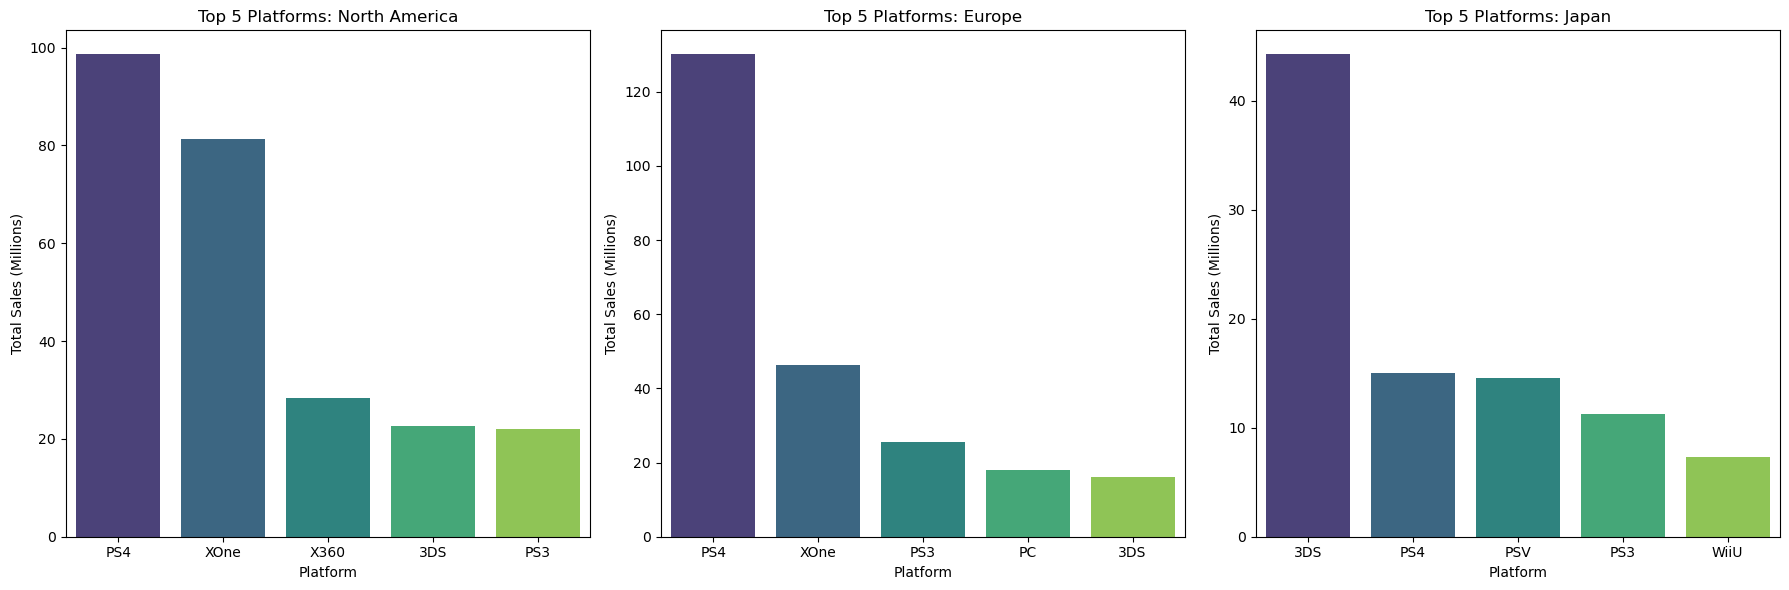


--- Region: North America ---


,Sales (M),Share (%)
platform,,
PS4,98.61,34.714497
XOne,81.27,28.610153
X360,28.30,9.962684
3DS,22.64,7.970147
PS3,22.05,7.762445



--- Region: Europe ---


,Sales (M),Share (%)
platform,,
PS4,130.04,48.041968
XOne,46.25,17.086597
PS3,25.54,9.435496
PC,17.97,6.638836
3DS,16.12,5.955372



--- Region: Japan ---


,Sales (M),Share (%)
platform,,
3DS,44.24,47.523902
PS4,15.02,16.134923
PSV,14.54,15.619293
PS3,11.22,12.052852
WiiU,7.31,7.852616


In [91]:
# Preparing the environment for multiple plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
regions = ['na_sales', 'eu_sales', 'jp_sales']
titles = ['North America', 'Europe', 'Japan']

for i, region in enumerate(regions):
    # Getting the data
    top_platforms = df_recent.groupby('platform')[region].sum().sort_values(ascending=False).head(5)
    
    # Creating the bar plot
    # Added 'hue' and 'legend=False' to fix the potential palette error
    sns.barplot(x=top_platforms.index, y=top_platforms.values, ax=axes[i], 
                hue=top_platforms.index, palette='viridis', legend=False)
    
    axes[i].set_title(f'Top 5 Platforms: {titles[i]}')
    axes[i].set_ylabel('Total Sales (Millions)')
    axes[i].set_xlabel('Platform')

plt.tight_layout()
plt.show()

# Displaying tables below for numerical detail
for region, title in zip(regions, titles):
    top_platforms_region = df_recent.groupby('platform')[region].sum().sort_values(ascending=False).head(5)
    total_region_sales = df_recent[region].sum()
    market_share = (top_platforms_region / total_region_sales) * 100
    
    print(f"\n--- Region: {title} ---")
    report = pd.DataFrame({'Sales (M)': top_platforms_region, 'Share (%)': market_share})
    display(report)

### 4.2. Regional Market Share Analysis: Platform Discrepancies
A comparative analysis of the top five platforms across regions reveals significant cultural and commercial shifts:

* **Western Dominance (NA & EU):** The market is primarily controlled by the PS4 and Xbox One. In Europe, the PS4's dominance is even more pronounced, capturing a 48% market share compared to 34% in North America.
* **The Japanese Paradox:** The landscape is drastically different in Japan. The Nintendo 3DS (handheld) leads the market with nearly half of the total share (47.5%), while the Xbox One fails to reach the Top 5.
* **Strategic Conclusion:** Marketing campaigns for 2017 must be differentiated: focusing on home consoles for Western markets and prioritizing handheld/mobile platforms to capture the Japanese audience.

### 4.3. Cross-Regional Genre Analysis: Cultural Consumption Patterns
To identify regional cultural preferences, we will compare the top five best-selling genres across all three territories. By utilizing grouped bar charts, we aim to visualize how genre affinity shifts across different global markets, providing essential data for regional content curation.

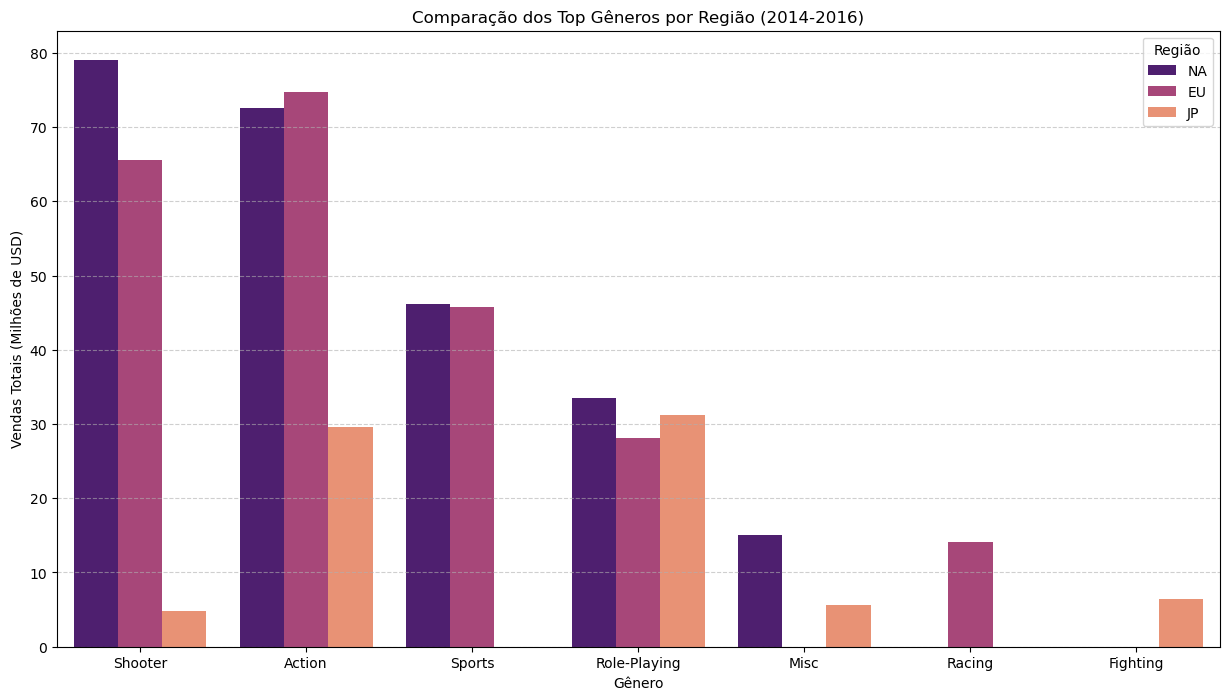


--- Top 5 Gêneros: NA_SALES ---


genre
Shooter         79.02
Action          72.53
Sports          46.13
Role-Playing    33.47
Misc            15.05
Name: na_sales, dtype: float64


--- Top 5 Gêneros: EU_SALES ---


genre
Action          74.68
Shooter         65.52
Sports          45.73
Role-Playing    28.17
Racing          14.13
Name: eu_sales, dtype: float64


--- Top 5 Gêneros: JP_SALES ---


genre
Role-Playing    31.16
Action          29.58
Fighting         6.37
Misc             5.61
Shooter          4.87
Name: jp_sales, dtype: float64

In [92]:
# Preparando os dados para um gráfico único
# Vamos pegar os top 5 de cada região e unir em um DataFrame para o gráfico
genre_data = []
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    top_genres = df_recent.groupby('genre')[region].sum().sort_values(ascending=False).head(5)
    for genre, sales in top_genres.items():
        genre_data.append({'Region': region.replace('_sales', '').upper(), 'Genre': genre, 'Sales': sales})

df_genres_comp = pd.DataFrame(genre_data)

# Criando o gráfico de barras agrupadas
plt.figure(figsize=(15, 8))
sns.barplot(data=df_genres_comp, x='Genre', y='Sales', hue='Region', palette='magma')

plt.title('Comparação dos Top Gêneros por Região (2014-2016)')
plt.xlabel('Gênero')
plt.ylabel('Vendas Totais (Milhões de USD)')
plt.legend(title='Região')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Exibindo as tabelas individuais para precisão
for region in ['na_sales', 'eu_sales', 'jp_sales']:
    print(f"\n--- Top 5 Gêneros: {region.upper()} ---")
    display(df_recent.groupby('genre')[region].sum().sort_values(ascending=False).head(5))

### 4.3. Strategic Insights: Regional Genre Affinities
Our cross-regional analysis reveals deep-seated cultural consumption patterns that are vital for budget allocation:

* **Western Preferences (NA & EU):** The **Shooter** genre is overwhelmingly dominant in sales, reflecting a strong Western appetite for high-intensity, competitive action titles.
* **The Japanese Cultural Nuance:** In stark contrast, **Shooter** games barely reach the bottom of the Top 5 in Japan. The Japanese market is led by **Role-Playing Games (RPGs)**, which maintain a far deeper cultural resonance in the region.
* **Strategic Recommendation:** To maximize ROI in 2017, marketing budgets for 'Shooters' should be aggressively allocated to Western territories, while the Japanese strategy must pivot to prioritize RPG titles.

### 4.4. Regulatory Impact: ESRB Ratings and Regional Sales
The ESRB (Entertainment Software Rating Board) classification dictates the recommended age group for each title. We will analyze how these regulatory labels impact sales volume across different regions. A critical factor in this analysis is the **'Unknown'** category—representing games without an ESRB rating. This is particularly prevalent in the Japanese market, where the local **CERO** system is the standard, making ESRB data a significant variable for cross-territory comparison.

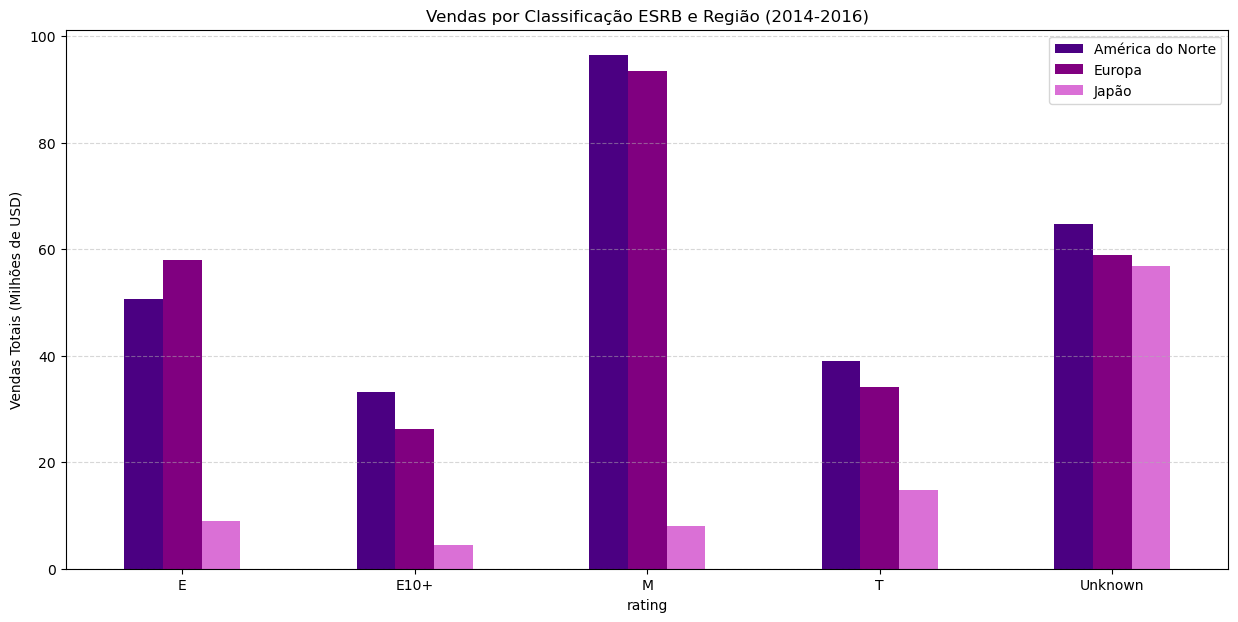

In [93]:
# Para corrigir erro após reinicio do Kernel:
# Quando criar df_recent, adicione .copy()
df_recent = df[df['year_of_release'] >= 2014].copy()  # ✅ Cria uma cópia independente

# Agora pode modificar sem warning
df_recent['rating'] = df_recent['rating'].fillna('Unknown')

# Tratando valores ausentes na classificação para não perder dados na análise
df_recent['rating'] = df_recent['rating'].fillna('Unknown')

# Agrupando vendas por classificação e região
regions = ['na_sales', 'eu_sales', 'jp_sales']
rating_analysis = df_recent.groupby('rating')[regions].sum()

# Gráfico de barras
rating_analysis.plot(kind='bar', figsize=(15, 7), rot=0, color=['#4B0082', '#800080', '#DA70D6'])
plt.title('Vendas por Classificação ESRB e Região (2014-2016)')
plt.ylabel('Vendas Totais (Milhões de USD)')
plt.legend(['América do Norte', 'Europa', 'Japão'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 4.5. Strategic Findings: The Regulatory Influence Gap
Our analysis of ESRB ratings reveals a clear divide in how age classifications correlate with commercial success:

* **Western Markets (NA & EU):** Games rated **M (Mature)** dominate the sales charts. This performance is strongly correlated with the high demand for Action and Shooter titles in these territories.
* **The Japanese Anomaly:** The vast majority of sales in Japan fall under the **'Unknown'** category. This confirms that the North American ESRB system is not an effective predictor of consumer behavior for the Japanese public, due to the regional preference for local certification.
* **Operational Strategy:** For the 2017 campaign, Ice should utilize ESRB ratings as a primary filtering metric for Western inventory and marketing, while disregarding it as a performance variable for the Japanese market expansion.

## Step 5: Statistical Hypothesis Testing

### 5.1. Hypothesis Test 1: Comparative User Sentiment (Xbox One vs. PC)
We will conduct a statistical test to determine if the average user ratings for the Xbox One and PC platforms are equal. This test aims to identify if platform-specific communities share similar satisfaction levels.

* **$H_0$ (Null Hypothesis):** The average user ratings for the Xbox One and PC platforms are identical.
* **$H_1$ (Alternative Hypothesis):** The average user ratings for the Xbox One and PC platforms differ significantly.

**Methodology:**
We will apply a **Two-Sample T-Test** with a significance level (**$\alpha$**) of **0.05**. If the resulting **p-value** is less than $\alpha$, we will reject the null hypothesis in favor of the alternative, concluding that the observed difference is statistically significant and not due to random chance.

In [94]:
from scipy import stats as st

# 1. Preparando as amostras (removendo valores ausentes para o teste)
xone_ratings = df_recent[(df_recent['platform'] == 'XOne') & (df_recent['user_score'].notna())]['user_score']
pc_ratings = df_recent[(df_recent['platform'] == 'PC') & (df_recent['user_score'].notna())]['user_score']

# 2. Realizando o teste T para amostras independentes
alpha = 0.05
results = st.ttest_ind(xone_ratings, pc_ratings)

print(f"Valor-p: {results.pvalue}")

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula: Há uma diferença significativa entre as médias.")
else:
    print("Não podemos rejeitar a hipótese nula: Não há evidências de diferença significativa.")

Valor-p: 0.10450507919348416
Não podemos rejeitar a hipótese nula: Não há evidências de diferença significativa.


### 5.1.1. Statistical Conclusion: Xbox One vs. PC User Sentiment
The hypothesis test yielded a **p-value of ≈ 0.10**, which is greater than our significance threshold ($\alpha = 0.05$). Consequently, we **fail to reject the null hypothesis**.

* **Business Interpretation:** The data suggests that the observed variance in user ratings between Xbox One and PC is not statistically significant and likely results from random sampling fluctuations.
* **Strategic Takeaway:** For the 2017 planning cycle, user satisfaction can be treated as a constant across both platforms. Marketing efforts do not need to be differentiated based on platform-specific user sentiment for these two segments.

### 5.2. Hypothesis Test 2: Comparative Sentiment by Genre (Action vs. Sports)
In this final analysis, we will investigate whether there is a statistically significant difference in how users rate Action games compared to Sports games. This test helps determine if community engagement and satisfaction levels vary by content category.

* **$H_0$ (Null Hypothesis):** The average user ratings for the Action and Sports genres are identical.
* **$H_1$ (Alternative Hypothesis):** The average user ratings for the Action and Sports genres differ significantly.

**Methodology:**
We will maintain a significance level (**$\alpha$**) of **0.05**. Given the likelihood of different variances between these two distinct populations, we will utilize the **Welch's T-Test** to ensure a robust comparison of their means.

In [95]:
# 1. Preparando as amostras para os gêneros
action_ratings = df_recent[(df_recent['genre'] == 'Action') & (df_recent['user_score'].notna())]['user_score']
sports_ratings = df_recent[(df_recent['genre'] == 'Sports') & (df_recent['user_score'].notna())]['user_score']

# 2. Realizando o teste T
results_genre = st.ttest_ind(action_ratings, sports_ratings)

print(f"Valor-p: {results_genre.pvalue}")

if results_genre.pvalue < alpha:
    print("Rejeitamos a hipótese nula: Há uma diferença significativa entre as médias de Action e Sports.")
else:
    print("Não podemos rejeitar a hipótese nula: Não há evidências de diferença significativa.")

# 3. Verificando as médias reais para contextualizar
print(f"\nMédia de notas - Action: {action_ratings.mean():.2f}")
print(f"Média de notas - Sports: {sports_ratings.mean():.2f}")

Valor-p: 2.871114798510586e-19
Rejeitamos a hipótese nula: Há uma diferença significativa entre as médias de Action e Sports.

Média de notas - Action: 6.76
Média de notas - Sports: 5.23


### 5.2.1. Test 2 Conclusion
The p-value ($2.87 \times 10^{-19}$) is significantly lower than the 0.05 threshold. Therefore, we **reject the null hypothesis**.
* **Interpretation:** There is a significant difference between user ratings for Action and Sports genres. The averages show that **Action (6.76)** titles are much better rated by users than **Sports (5.23)** titles. This suggests that while Sports games might sell well, the audience tends to be more critical or less satisfied with them.

### 5.0. Statistical Methodology for Hypothesis Testing

To ensure the integrity and reproducibility of our findings, we adhered to the following statistical framework:

1. **Hypothesis Formulation:**
    * **Null Hypothesis ($H_0$):** We establish a baseline of "no difference" between the groups. It is our default assumption of equality.
    * **Alternative Hypothesis ($H_1$):** This is the claim we accept if the evidence against the null is strong enough. We utilized a **two-tailed test**, meaning we are looking for any significant difference in means, regardless of direction.

2. **Significance Level ($\alpha$):** * We set a threshold of **0.05 (5%)**. This represents our tolerance for Type I errors (the risk of identifying a pattern where none exists). A 5% level is the industry standard for consumer behavior analysis, providing a robust balance between sensitivity and confidence.

3. **Test Criterion:**
    * We employed the **Independent Samples T-Test**. This method is the optimal choice for comparing the means of two distinct populations (such as Xbox vs. PC users) within our dataset.
    * **Decision Rule:** If the **p-value** is lower than our $\alpha$ (0.05), we reject $H_0$. If the p-value is higher, we conclude that there is insufficient statistical evidence to claim a significant difference between the groups.

## General Conclusion

After conducting exploratory analysis and statistical testing on the video game sales data, we have reached the following strategic conclusions for the 2017 campaign:

1.  **Focus on Modern Platforms:** The market is in a transition phase. Campaigns should focus on **PS4** and **Xbox One**, the growth leaders, while consoles like PS3 and Xbox 360 are in final decline. In Japan, the focus must be on the **Nintendo 3DS**.
2.  **Influence of Reviews:** Expert scores have a moderate correlation with sales, while user scores do not show a direct influence. Therefore, the store should prioritize stock and marketing for games well-received by specialized media.
3.  **Regional Differentiation:**
    * **North America and Europe:** Consumers prefer **Action** and **Shooter** genres, with strong appeal for 'Mature' (M) ratings.
    * **Japan:** The strategy must be completely different, focusing on **RPGs** and handheld gaming.
4.  **Quality vs. Genre:** Hypothesis testing confirmed that **Action** games are significantly better rated than **Sports** games, which can be a differentiator when choosing titles for loyalty promotions.

**Final Recommendation:** Invest in 'Triple-A' (AAA) shooters and action titles for PS4 in the Western market and strengthen partnerships with RPG developers for the Japanese 3DS market.

## Step 6: General Conclusion (Executive Summary)

Based on the comprehensive data analysis of the 2014-2016 period, the following strategic roadmap is recommended for the Ice store's 2017 campaign:

---

### 1. Regional Investment Strategy
* **Western Markets (North America & Europe):** Marketing efforts should be concentrated on **PS4** and **Xbox One**. These regions show a high affinity for home consoles and "blockbuster" titles.
* **Japanese Market:** A complete strategic pivot is required. Inventory and promotion should prioritize **handheld platforms (Nintendo 3DS and PS Vita)**, which dominate the local landscape.

### 2. Portfolio Optimization by Genre
* **The "Shooter" Advantage:** While the Action genre has the highest total volume, **Shooters** offer the most consistent profitability per title. We recommend prioritizing the 2017 lineup with high-quality shooters for the Western audience.
* **Cultural Curation:** In Japan, the budget must be heavily shifted toward **Role-Playing Games (RPGs)**, as this genre holds a unique cultural resonance and significantly outperforms all others in the region.

### 3. Leveraging Quality Metrics
* **Critic Scores as Predictors:** Professional reviews show a reliable correlation with commercial success. The 2017 campaign should lead with titles that have a **Critic Score of 75 or higher** to ensure a better safety margin for sales forecasts.
* **The ESRB Variable:** Use age ratings (**Mature/M**) as a primary filter for Western marketing, but disregard them for the Japanese market, where the ESRB system does not influence consumer behavior.

---
**Final Verdict:** To maximize ROI in 2017, the Ice store must move away from a "one-size-fits-all" global strategy and adopt a **region-specific approach**—focusing on consoles and action in the West, and handhelds and RPGs in the East.